# Pràctica Bloc III

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import zip_longest
from matplotlib.ticker import LinearLocator

train_raw, test_raw = pd.read_csv("data/train.csv"), pd.read_csv("data/test.csv")
print(f"Dimensions del dataset (train): {train_raw.shape}")
print(f"Dimensions del dataset (test): {test_raw.shape}")
train_raw.head()

Dimensions del dataset (train): (103904, 25)
Dimensions del dataset (test): (25976, 25)


,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [2]:
# eliminam columnes que no aporten informació
ignore = { "Unnamed: 0", "id" }
train_raw.drop(columns=ignore, inplace=True, errors="ignore")
test_raw.drop(columns=ignore, inplace=True, errors="ignore")
print(train_raw.columns.tolist())

['Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes', 'satisfaction']


In [3]:
# comprovam quines columnes tenen valors invalids (NaNs)
train_raw.isna().sum() + test_raw.isna().sum()

Gender                                 0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Inflight wifi service                  0
Departure/Arrival time convenient      0
Ease of Online booking                 0
Gate location                          0
Food and drink                         0
Online boarding                        0
Seat comfort                           0
Inflight entertainment                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Inflight service                       0
Cleanliness                            0
Departure Delay in Minutes             0
Arrival Delay in Minutes             393
satisfaction                           0
dtype: int64

In [4]:
# reempleçam els NaNs per a la mitjana de la seva columna
nancol = "Arrival Delay in Minutes"
train_raw[nancol] = train_raw[nancol].fillna(train_raw[nancol].mean())
test_raw[nancol] = test_raw[nancol].fillna(test_raw[nancol].mean())
train_raw.isna().sum() + test_raw.isna().sum()

Gender                               0
Customer Type                        0
Age                                  0
Type of Travel                       0
Class                                0
Flight Distance                      0
Inflight wifi service                0
Departure/Arrival time convenient    0
Ease of Online booking               0
Gate location                        0
Food and drink                       0
Online boarding                      0
Seat comfort                         0
Inflight entertainment               0
On-board service                     0
Leg room service                     0
Baggage handling                     0
Checkin service                      0
Inflight service                     0
Cleanliness                          0
Departure Delay in Minutes           0
Arrival Delay in Minutes             0
satisfaction                         0
dtype: int64

In [5]:
# these are the columns with a level of satisfaction values in [0-5]
lvlcols = { "Inflight wifi service", "Departure/Arrival time convenient", "Ease of Online booking", "Gate location",
           "Food and drink", "Online boarding", "Seat comfort", "Inflight entertainment", "On-board service",
           "Leg room service", "Baggage handling", "Checkin service", "Inflight service", "Cleanliness" }
# get columns without numeric values
catcols = set(train_raw.select_dtypes(exclude=[np.number]).columns)
# get columns with numeric values 
numcols = set(train_raw.select_dtypes(include=[np.number]).columns)
numcols ^= lvlcols # remaining columns that are numeric but do not represent a satisfacion level

# convert columns with categoric values to numeric values
catvals = { col: { n: i for i, n in enumerate(train_raw[col].unique()) } for col in catcols }

lalign = 4
sep = "-" * 80

print("Columns with categoric values")
lmax = max(len(s) for s in catcols)
print("\n".join(" " * lalign + f"{col:{lmax}s} : {catvals[col]}" for col in catcols))
print(sep)

print("Columns with satisfaction level values [0-5]")
print("\n".join(" " * lalign + col for col in lvlcols))
print(sep)

print("Columns with numeric values")
print("\n".join(" " * lalign + col for col in numcols))

Columns with categoric values
    Customer Type  : {'Loyal Customer': 0, 'disloyal Customer': 1}
    Class          : {'Eco Plus': 0, 'Business': 1, 'Eco': 2}
    satisfaction   : {'neutral or dissatisfied': 0, 'satisfied': 1}
    Gender         : {'Male': 0, 'Female': 1}
    Type of Travel : {'Personal Travel': 0, 'Business travel': 1}
--------------------------------------------------------------------------------
Columns with satisfaction level values [0-5]
    Inflight entertainment
    Departure/Arrival time convenient
    On-board service
    Seat comfort
    Inflight service
    Cleanliness
    Checkin service
    Inflight wifi service
    Ease of Online booking
    Gate location
    Leg room service
    Food and drink
    Baggage handling
    Online boarding
--------------------------------------------------------------------------------
Columns with numeric values
    Flight Distance
    Age
    Arrival Delay in Minutes
    Departure Delay in Minutes


In [6]:
train, test = train_raw.copy(), test_raw.copy()
for col, val in catvals.items(): train[col], test[col] = train_raw[col].map(val), test_raw[col].map(val)

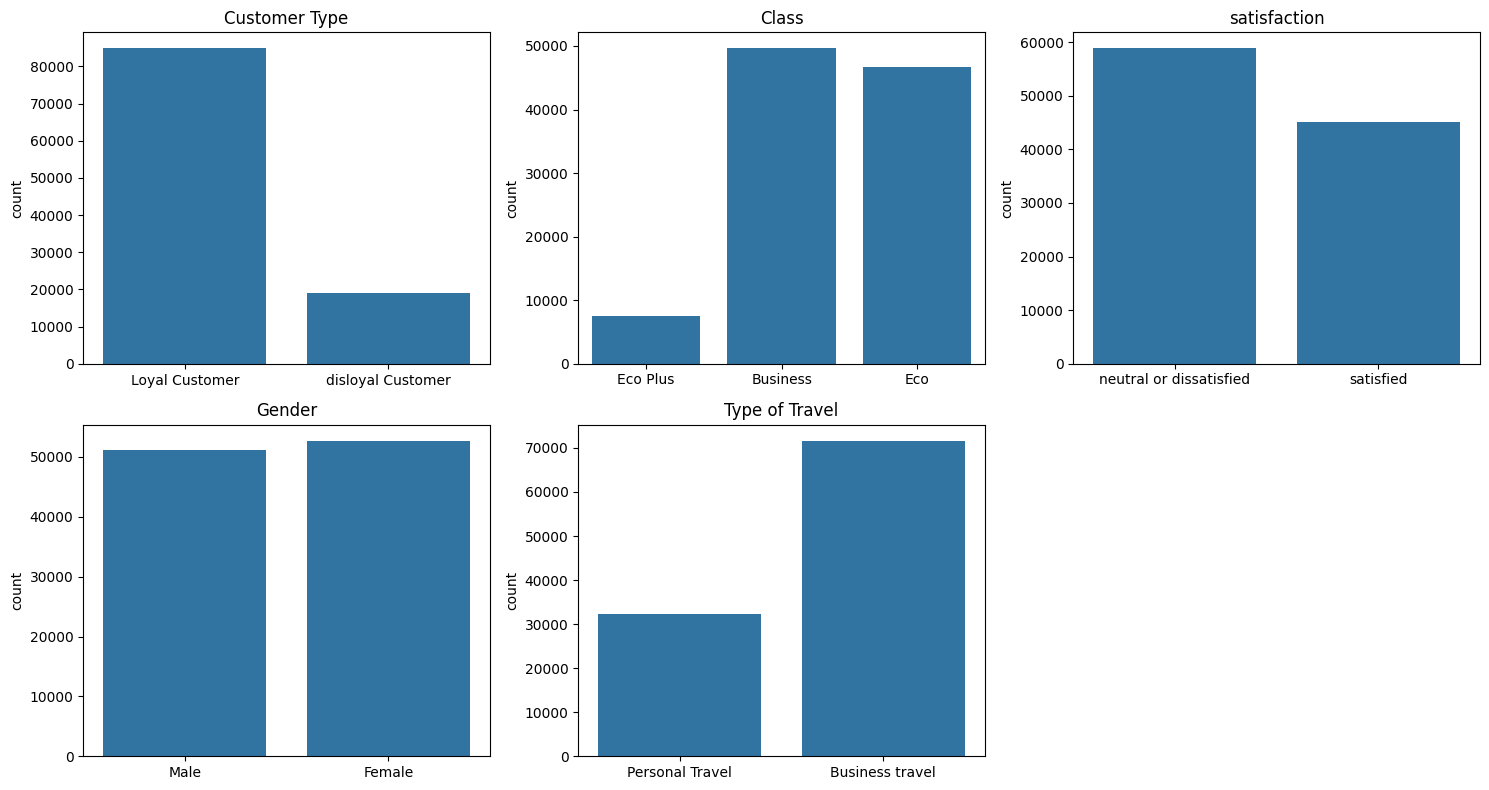

In [7]:
n = len(catcols)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.ravel()

for ax, col in zip_longest(axes, catcols):
  if col:
    sns.countplot(data=train, x=col, ax=ax)
    ax.set_title(col)
    labels = list(catvals[col].keys())
    ax.set_xticks(np.arange(0, len(labels)), labels)
    ax.set_xlabel("")
  else:
    ax.axis("off")

plt.tight_layout()
plt.show()

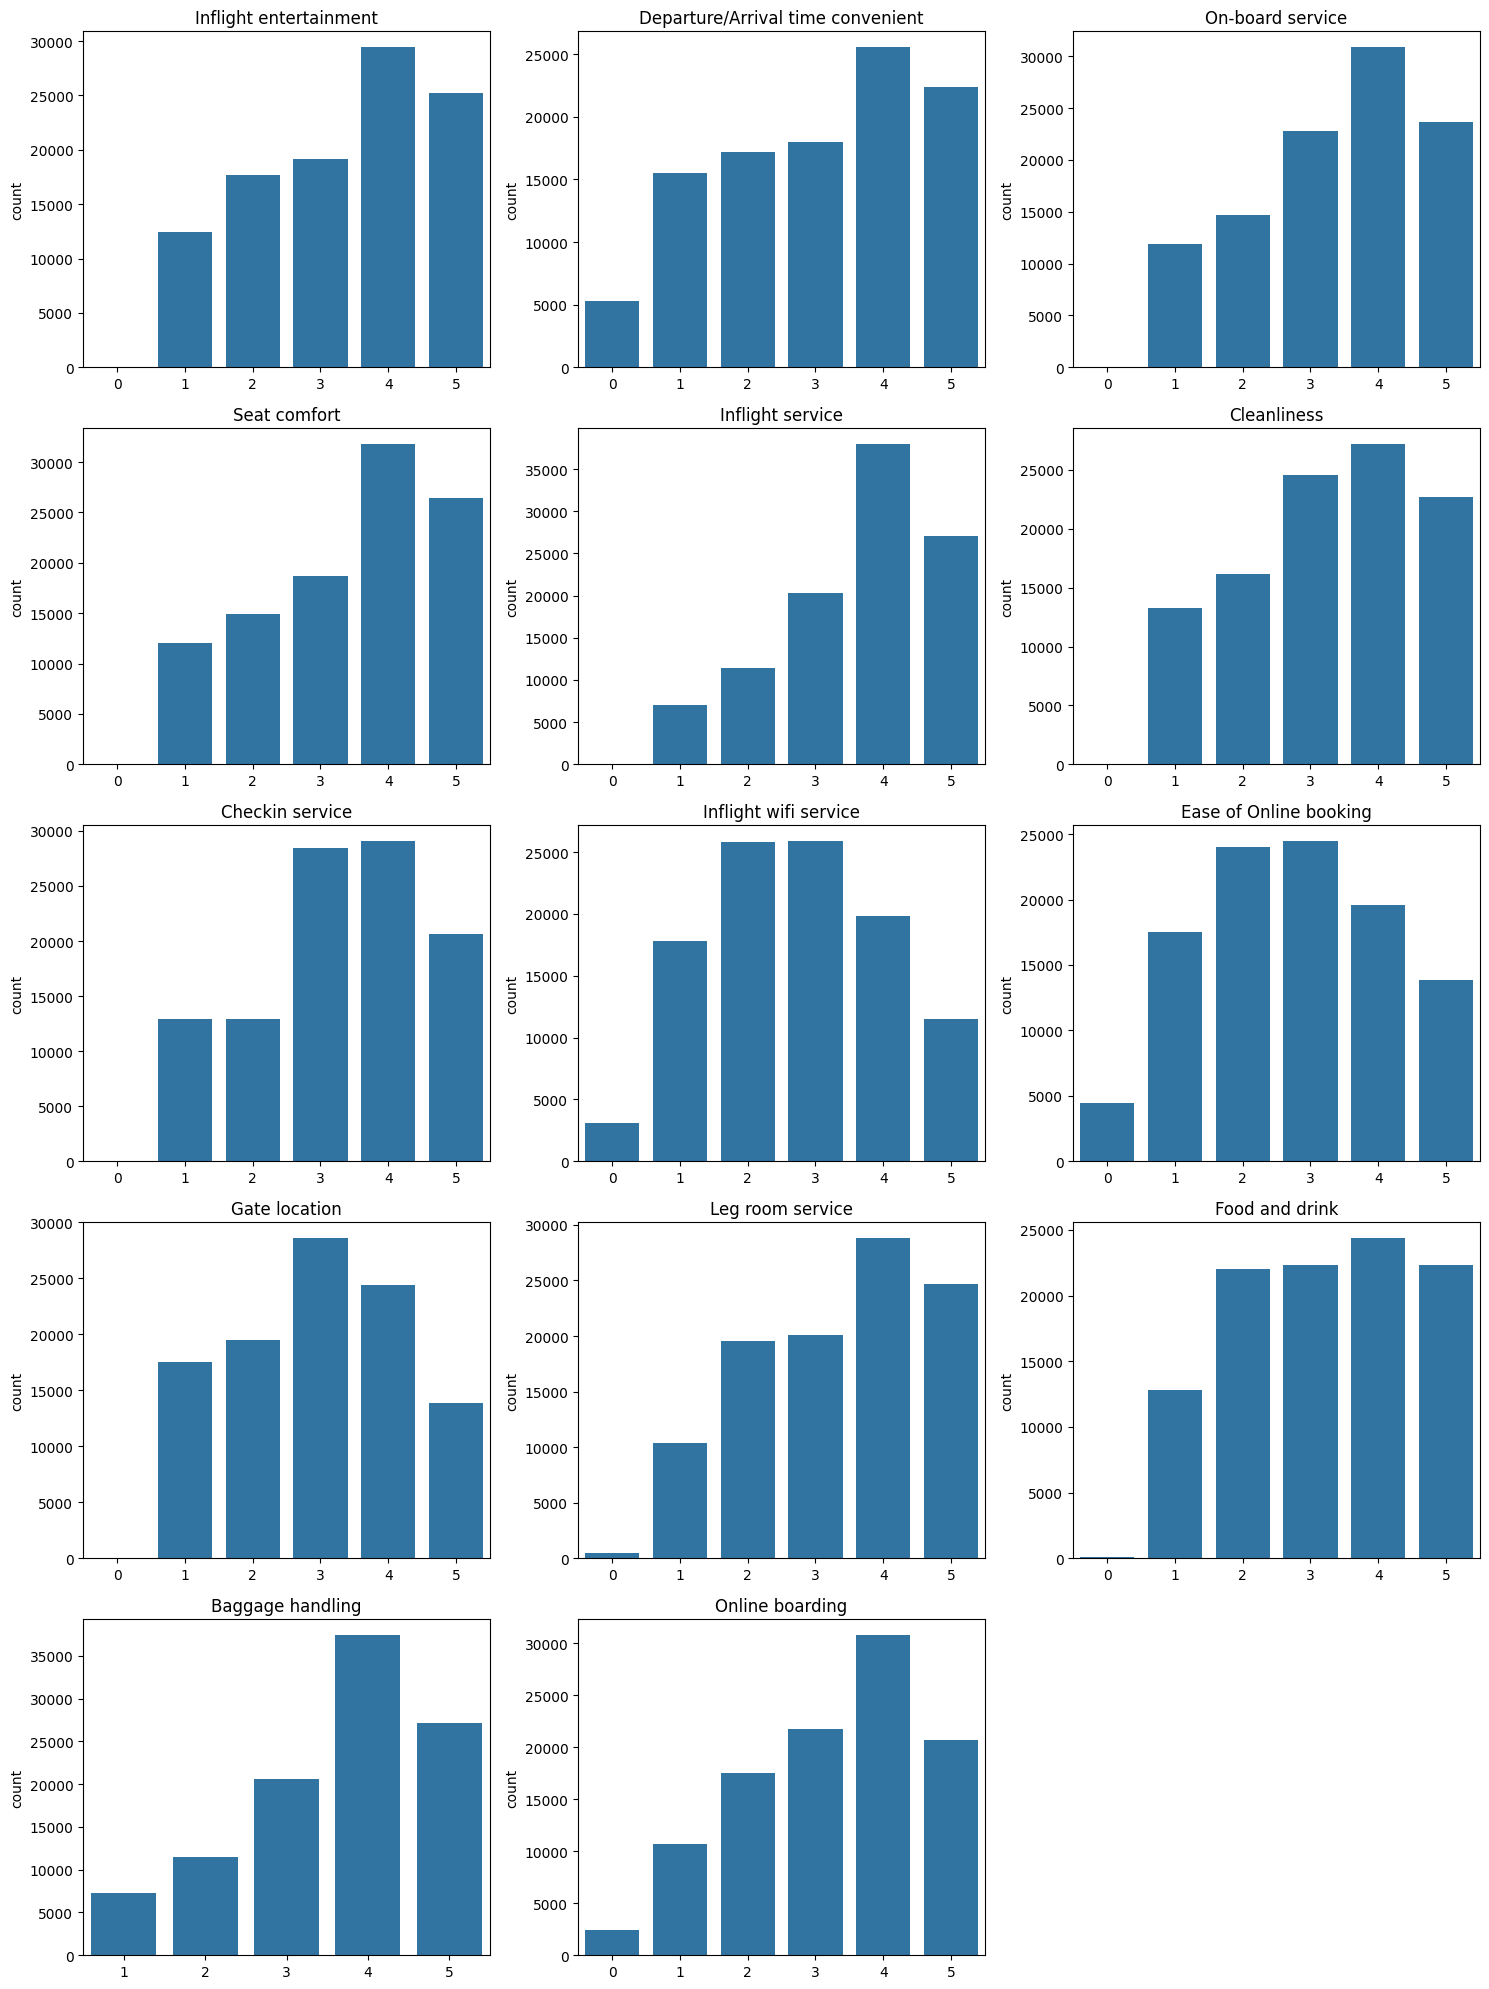

In [8]:
n = len(lvlcols)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.ravel()

for ax, col in zip_longest(axes, lvlcols):
  if col:
    sns.countplot(data=train, x=col, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
  else:
    ax.axis("off")

plt.tight_layout()
plt.show()

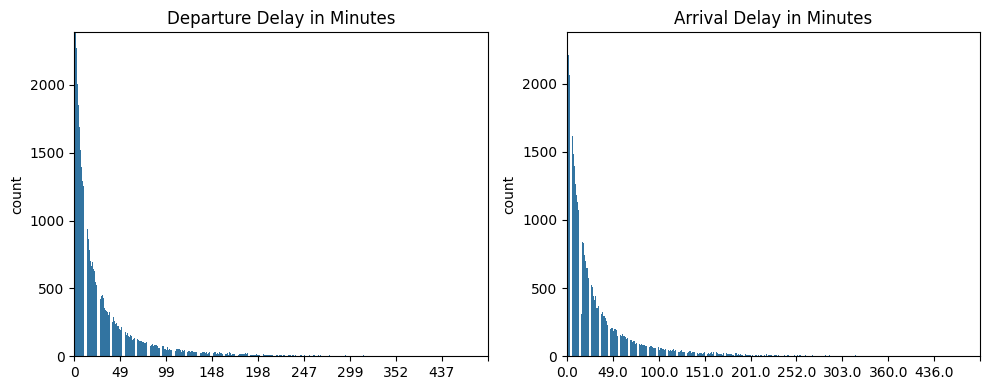

In [9]:
cols = ["Departure Delay in Minutes", "Arrival Delay in Minutes"]
n = len(cols)
ncols = 2
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.ravel()

from matplotlib.ticker import LinearLocator

for ax, col in zip_longest(axes, cols):
  if col:
    sns.countplot(data=train, x=col, ax=ax)
    ax.set_title(col)
    m = train[col].max()
    ax.set_ylim(0, m * 1.5)
    ax.xaxis.set_major_locator(LinearLocator(numticks=10))
    ax.set_xlabel("")
  else:
    ax.axis("off")

plt.tight_layout()
plt.show()

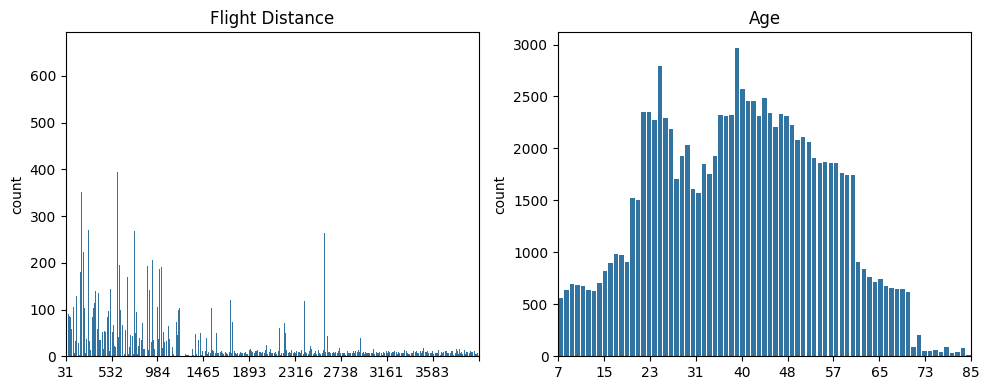

In [10]:
cols = ["Flight Distance", "Age"]
n = len(cols)
ncols = 2
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.ravel()

for ax, col in zip_longest(axes, cols):
  if col:
    sns.countplot(data=train, x=col, ax=ax)
    ax.set_title(col)
    ax.xaxis.set_major_locator(LinearLocator(numticks=10))
    ax.set_xlabel("")
  else:
    ax.axis("off")

plt.tight_layout()
plt.show()

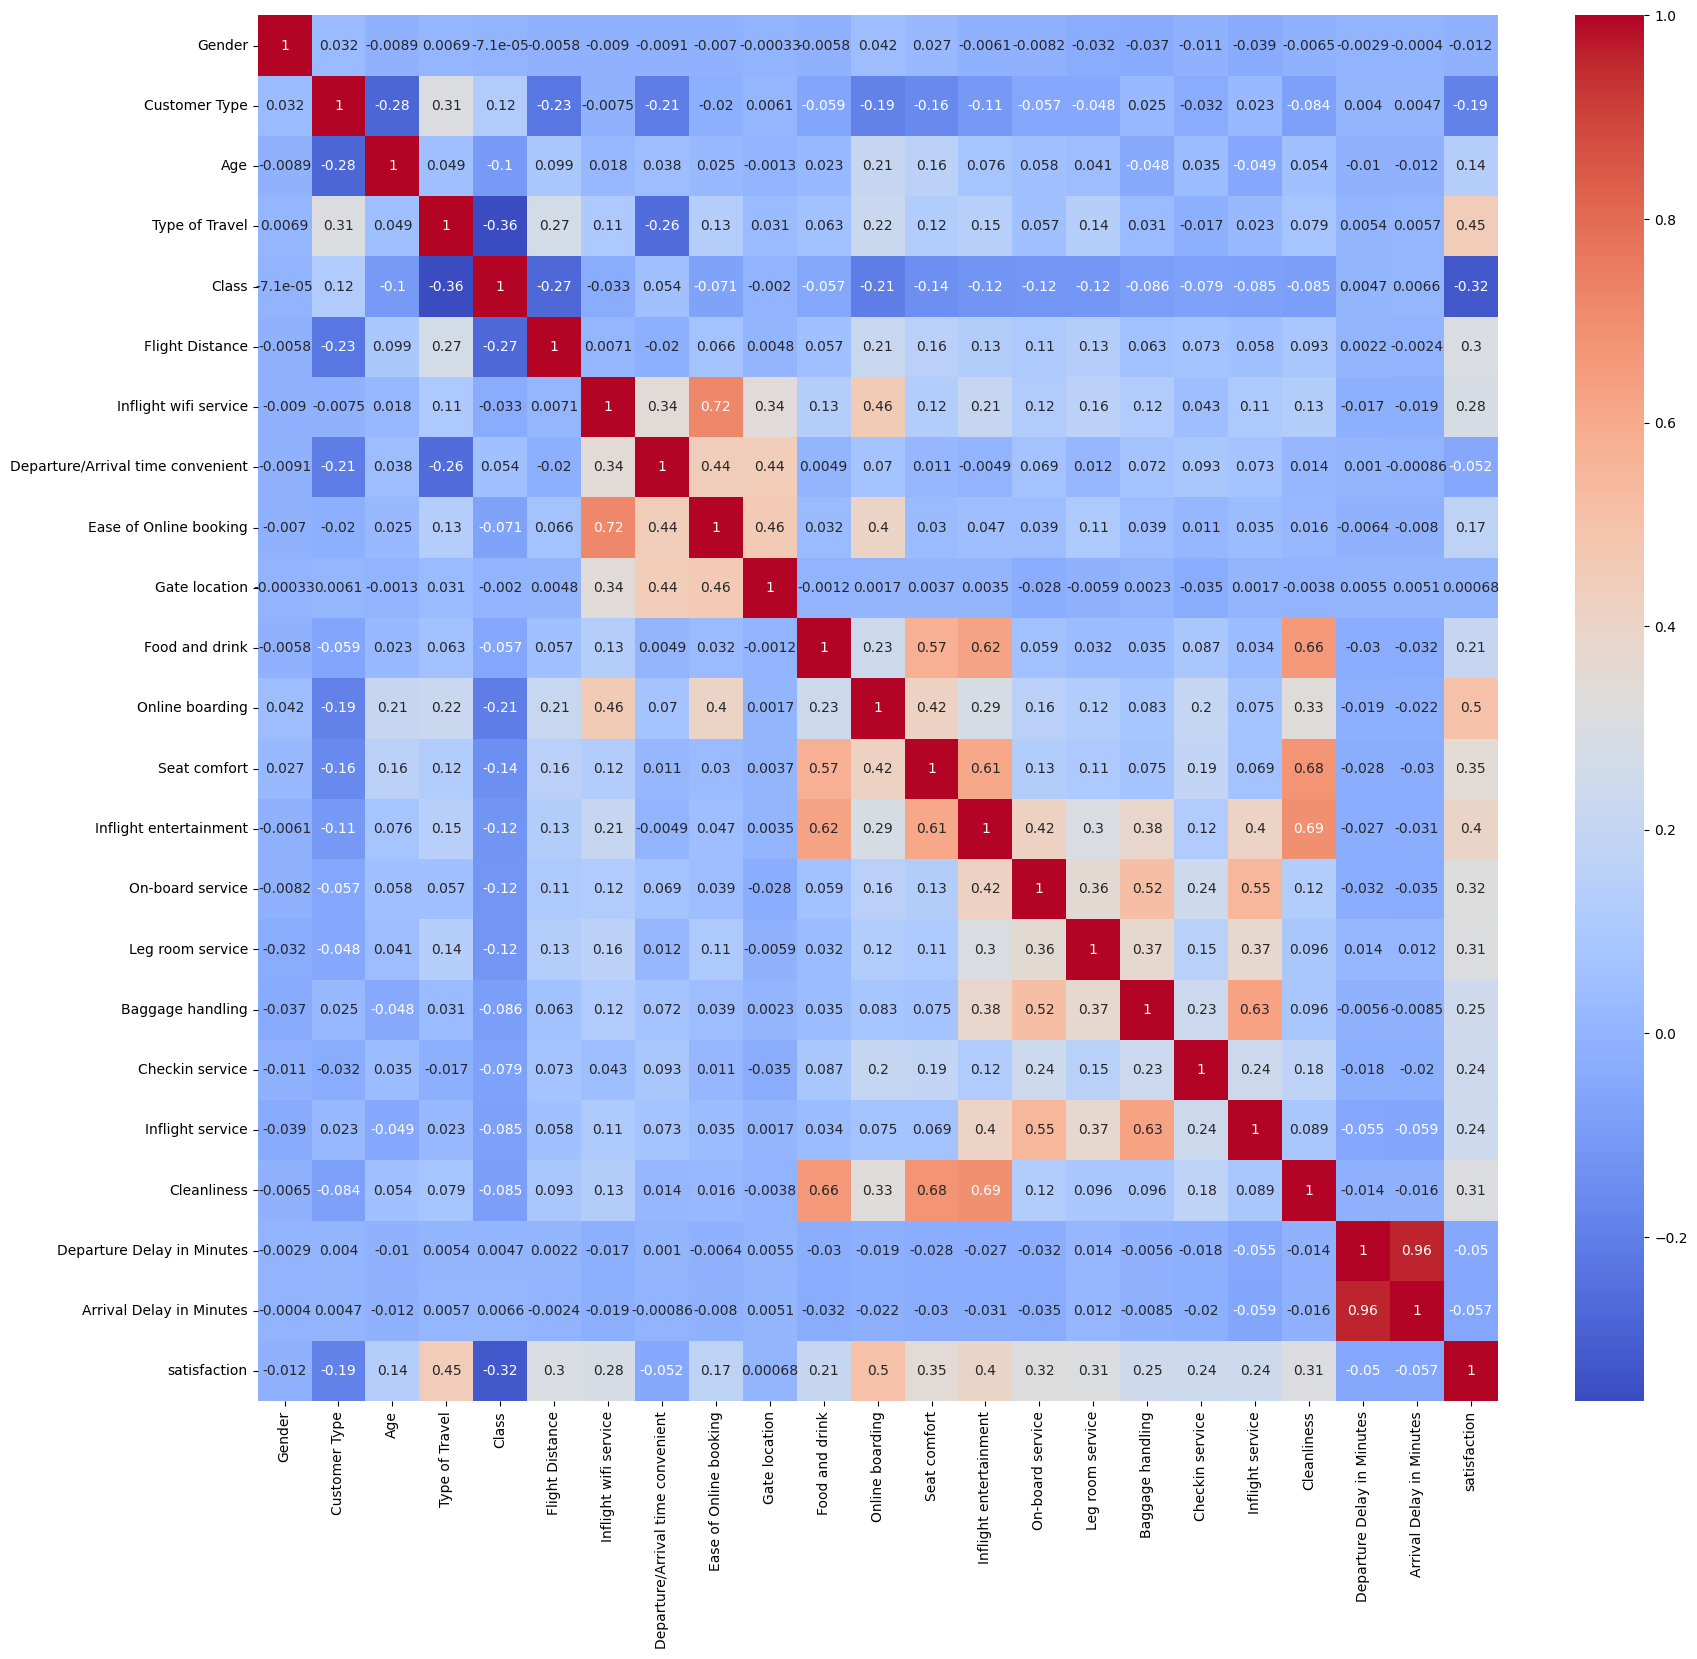

In [11]:
plt.figure(figsize=(20, 18))
sns.heatmap(train.corr(), annot=True, cmap="coolwarm")
plt.show()

In [12]:
from sklearn.preprocessing import StandardScaler

features = ["Customer Type", "Age", "Class", "Flight Distance",
            "Inflight wifi service", "Ease of Online booking", "Food and drink", "Online boarding", "Seat comfort",
            "Inflight entertainment", "On-board service", "Leg room service", "Baggage handling", "Checkin service",
            "Inflight service", "Cleanliness"]
X_train, X_test = train[features], test[features]
y_train, y_test = train["satisfaction"], test["satisfaction"]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import Perceptron, LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

models = {
  "Perceptron": Perceptron(max_iter=1000),
  "Logistic Regression": LogisticRegression(max_iter=1000),
  "SVM": SVC(max_iter=1000),
  "Tree": DecisionTreeClassifier(),
  "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

for name, model in models.items():
  print(f"******** {name} ********")

  model.fit(X_train_scaled, y_train)

  y_train_pred = model.predict(X_train_scaled)
  y_test_pred = model.predict(X_test_scaled)

  acc_train = accuracy_score(y_train, y_train_pred)
  acc_test = accuracy_score(y_test, y_test_pred)

  print(f"train acc: {acc_train:6.4f}")
  print(f" test acc: {acc_test:6.4f}")

  if acc_train - acc_test > 0.1: print("WARNING: possible overfitting")

  print()

******** Perceptron ********
train acc: 0.7524
 test acc: 0.7476

******** Logistic Regression ********
train acc: 0.8288
 test acc: 0.8265

******** SVM ********


/Users/serafi/.pyenv/versions/3.14.0/lib/python3.14/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


train acc: 0.7187
 test acc: 0.7171

******** Tree ********
train acc: 1.0000
 test acc: 0.9280

******** Random Forest ********
train acc: 1.0000
 test acc: 0.9530

